# Central Limit Theorem: simulation in Python

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/04-central-limit-theorem-notebook.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

The central limit theorem (CLT) explains a surprising pattern: even when individual observations are skewed or discrete, the **sample mean** often has an approximately normal distribution when the sample size is sufficiently large.

This notebook uses NumPy simulations to make that pattern visible. It is a companion to the browser interactive and is designed to run directly in Google Colab.

## Learning objectives

By the end of this notebook, you should be able to:

- distinguish one observation, one sample, and a sample mean;
- simulate repeated samples from a population;
- build the distribution of sample means; and
- explain why increasing the sample size changes that distribution, while increasing the number of trials only reveals it more clearly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(seed=4520)

## 1. One population, many samples

Suppose a population produces observations denoted by $X$. A **sample** contains $n$ independent observations from that population. Its **sample mean** is

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i.$$

To study how $\bar{x}$ varies, we repeat the whole sampling process $B$ times. This gives us $B$ sample means.

In [2]:
def simulate_sample_means(draw_observations, sample_size, trials, rng):
    """Draw `trials` samples and return the samples and their means."""
    samples = draw_observations(rng, size=(trials, sample_size))
    means = samples.mean(axis=1)
    return samples, means


def show_clt_experiment(draw_observations, sample_size, trials, rng, title):
    """Plot the population, one sample, and all simulated sample means."""
    population_preview = draw_observations(rng, size=10_000)
    samples, means = simulate_sample_means(
        draw_observations, sample_size=sample_size, trials=trials, rng=rng
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)
    axes[0].hist(population_preview, bins=35, color="#70a5c8", edgecolor="white")
    axes[0].set(title="Population preview", ylabel="Count")

    axes[1].hist(samples[0], bins=16, color="#d77732", edgecolor="white")
    axes[1].axvline(samples[0].mean(), color="#b65420", linestyle="--", label="sample mean")
    axes[1].set(title=f"One sample (n = {sample_size})")
    axes[1].legend()

    axes[2].hist(means, bins=30, color="#457eaa", edgecolor="white")
    axes[2].axvline(means.mean(), color="#355766", linestyle="--", label="mean of sample means")
    axes[2].set(title=f"Distribution of {trials} sample means")
    axes[2].legend()

    fig.suptitle(title, fontsize=14)
    plt.show()
    return means

## 2. A right-skewed population: exponential observations

An exponential distribution can model a waiting time under a simple constant-rate assumption—for example, the time until the next event in a process. It is strongly right-skewed, so it is a useful CLT example.

Start with $n=1$. In this case, every sample mean is just one observation, so the rightmost plot should look much like the population.

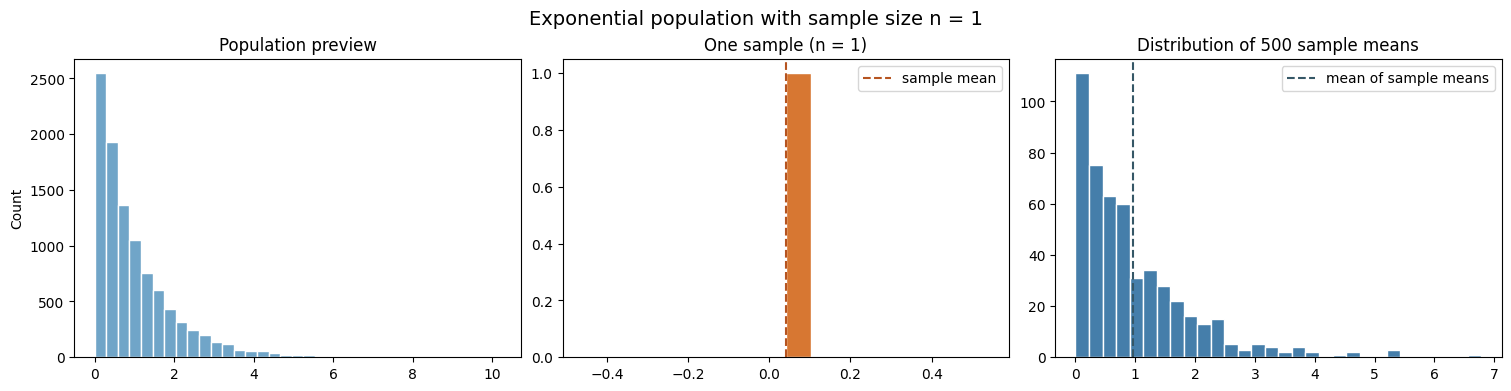

In [3]:
draw_exponential = lambda rng, size: rng.exponential(scale=1, size=size)

means_n1 = show_clt_experiment(
    draw_exponential, sample_size=1, trials=500, rng=rng,
    title="Exponential population with sample size n = 1"
)

Now increase the sample size to $n=30$. The individual observations are still exponential, but each point in the rightmost plot is now an average of 30 independent observations.

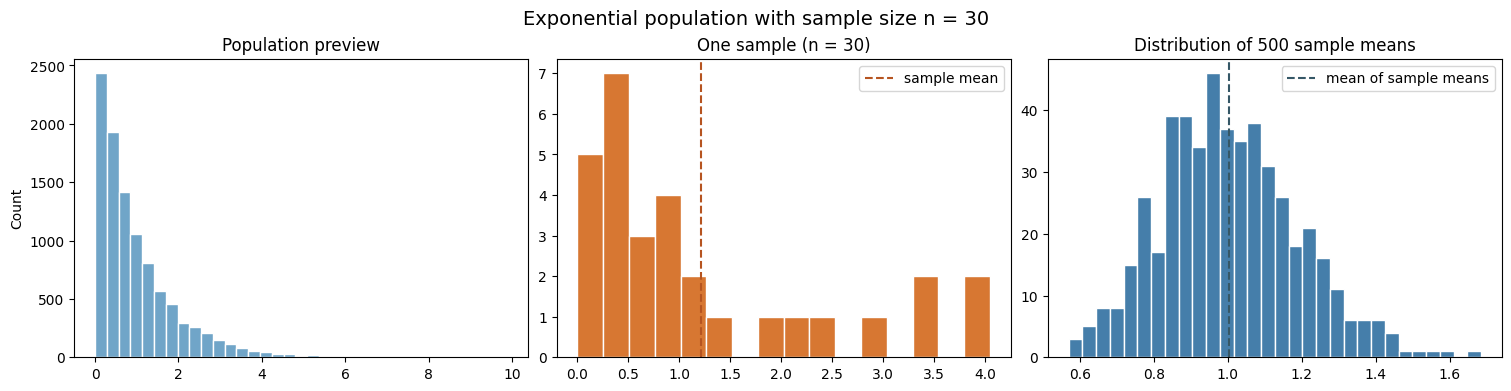

In [4]:
means_n30 = show_clt_experiment(
    draw_exponential, sample_size=30, trials=500, rng=rng,
    title="Exponential population with sample size n = 30"
)

## 3. Change the sample size, not the population

The CLT predicts that the distribution of sample means becomes narrower as $n$ grows. The standard deviation of the sample mean is called the **standard error**; under the usual independent-sampling assumption, it decreases in proportion to $1 / \sqrt{n}$.

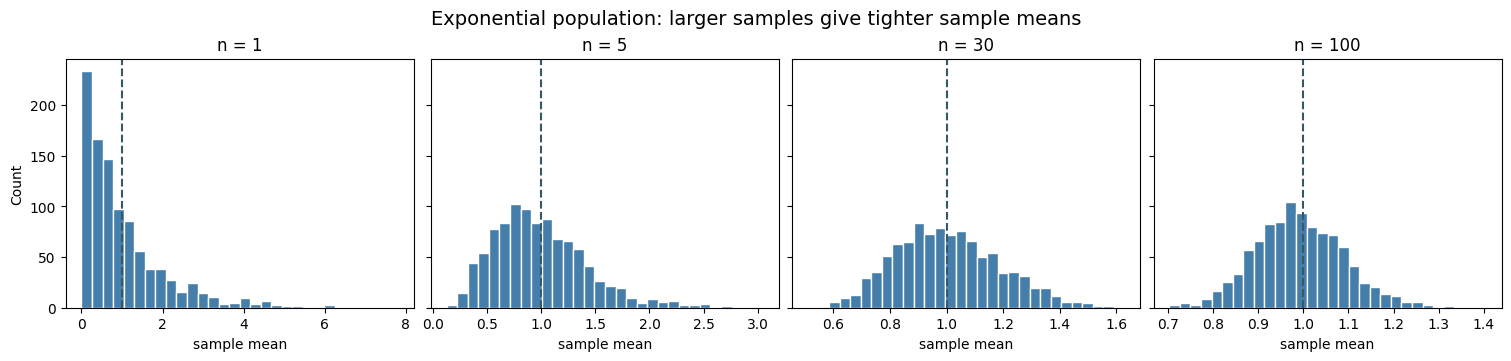

In [5]:
sample_sizes = [1, 5, 30, 100]
trials = 1_000

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 3.5), sharey=True, constrained_layout=True)
for ax, sample_size in zip(axes, sample_sizes):
    _, means = simulate_sample_means(draw_exponential, sample_size, trials, rng)
    ax.hist(means, bins=30, color="#457eaa", edgecolor="white")
    ax.axvline(1, color="#355766", linestyle="--")
    ax.set(title=f"n = {sample_size}", xlabel="sample mean")
axes[0].set_ylabel("Count")
fig.suptitle("Exponential population: larger samples give tighter sample means", fontsize=14)
plt.show()

## 4. A discrete population: Poisson counts

The CLT does not require continuous observations. A Poisson distribution models a count of events in a fixed interval—for example, the number of detected defects or arrivals during a production interval. Here the population is discrete, but averages of repeated samples can still be approximately normal.

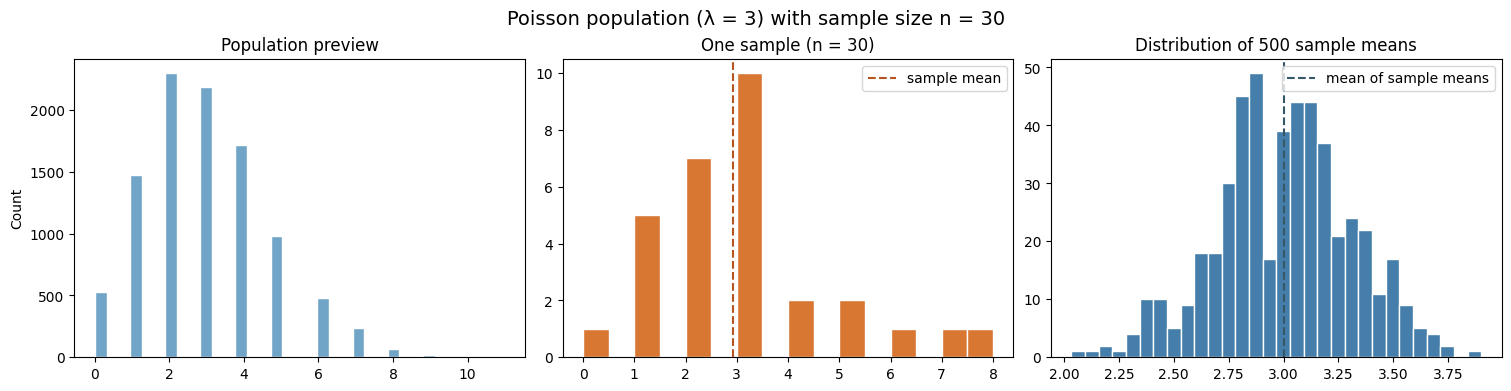

In [6]:
draw_poisson = lambda rng, size: rng.poisson(lam=3, size=size)

poisson_means = show_clt_experiment(
    draw_poisson, sample_size=30, trials=500, rng=rng,
    title="Poisson population (λ = 3) with sample size n = 30"
)

## Check-in

1. Keep the exponential population and set `sample_size=100`. How does the spread of the sample means compare with `sample_size=30`?
2. Keep `sample_size=30`, but increase `trials` from 500 to 2,000. Does this change the spread of a sample mean, or only how clearly you see its distribution?
3. Replace the Poisson draw function with `rng.binomial(n=10, p=0.2, size=size)`. What does the distribution of sample means look like?

In [7]:
# Try one modification at a time.
# means_n100 = show_clt_experiment(
#     draw_exponential, sample_size=100, trials=500, rng=rng,
#     title="Exponential population with sample size n = 100"
# )

# draw_binomial = lambda rng, size: rng.binomial(n=10, p=0.2, size=size)
# binomial_means = show_clt_experiment(
#     draw_binomial, sample_size=30, trials=500, rng=rng,
#     title="Binomial population with sample size n = 30"
# )

# Return to the Foundations page when you are finished.

[← Return to Foundations](index.qmd)